In [119]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

#from analysis.load_run_data import load_run_data
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from rastermap import Rastermap
import numpy as np
from itertools import combinations
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import pickle
from tqdm import tqdm

from sklearn.linear_model import LinearRegression, Lasso, MultiTaskLasso
from sklearn.metrics import r2_score
import pandas as pd

from analysis.utils import fit_rastermap, plot_rastermap_with_rewards_actions
import pickle
import json
from pathlib import Path
import pandas as pd

In [120]:
def load_intervention_data(df_metadata,
                           intervention_type=None,
                           hinge_1_value=None,
                           seed=None,
                           selection_type=None,
                           selection_threshold=None,
                           variable=None,
                           pca_component_idx=None):
    """
    Load intervention data from directories matching the specified criteria.
    
    Parameters can be single values or lists. If a parameter is None, it matches all values.
    
    Returns:
        pd.DataFrame: DataFrame with config info and episode data
    """

    # Convert single values to lists for uniform handling
    def to_list(val):
        if val is None:
            return None
        return val if isinstance(val, list) else [val]

    type_list = to_list(intervention_type)
    hinge_1_value_list = to_list(hinge_1_value)
    seed_list = to_list(seed)
    selection_type_list = to_list(selection_type)
    selection_threshold_list = to_list(selection_threshold)
    variable_list = to_list(variable)
    pca_component_idx_list = to_list(pca_component_idx)

    # Filter configs based on criteria
    filtered_configs = []
    for idx, config in df_metadata.iterrows():
        # Check each criterion
        if type_list is not None and config.get('config_type') not in type_list:
            continue
        if hinge_1_value_list is not None and config.get(
                'config_hinge_1_value') not in hinge_1_value_list:
            continue
        if seed_list is not None and config.get('config_seed') not in seed_list:
            continue
        if selection_type_list is not None and config.get(
                'config_selection_type') not in selection_type_list:
            continue
        if selection_threshold_list is not None and config.get(
                'config_selection_threshold') not in selection_threshold_list:
            continue
        if variable_list is not None and config.get(
                'config_variable') not in variable_list:
            continue
        if pca_component_idx_list is not None and config.get(
                'config_pca_component_idx') not in pca_component_idx_list:
            continue

        filtered_configs.append(config)

    print(f"Found {len(filtered_configs)} configurations")
    # Load episode data for each matching config
    results = []
    for config in tqdm(filtered_configs):
        directory = Path(config['directory'])
        episode_path = directory / "activations" / "episode_0000.pkl"

        if episode_path.exists():
            # Load the pickled episode data
            with open(episode_path, 'rb') as f:
                episode_data = pickle.load(f)

            # Unflatten the data structure
            episode_data = episode_data['data']
            for key, value in episode_data.items():

                if key == 'latent_states':
                    config[key] = value.squeeze()
                else:
                    config[key] = value

            results.append(config)

    return pd.DataFrame(results)


def compute_success(df_data, threshold_angle=0.1, consecutive_steps=100):
    """
    Compute whether the pole is upright (straight) for consecutive_steps time points.
    
    Args:
        df_data: DataFrame with 'observations' column containing state arrays
        threshold_angle: Maximum angle deviation from vertical (in radians) to consider "straight"
        consecutive_steps: Number of consecutive steps required for success
    
    Returns:
        df_data: DataFrame with added 'success' column
    """
    success = []

    for idx in range(len(df_data)):
        observations = np.array(df_data['observations'].iloc[idx])

        # Extract cos and sin of pole angle (dimensions 1 and 2)
        cos_angle = observations[:, 1]
        sin_angle = observations[:, 2]

        # Compute actual angle from cos and sin
        angles = np.arctan2(sin_angle, cos_angle)

        # Check if angle is within threshold (close to 0, which is upright)
        is_straight = np.abs(angles) < threshold_angle

        # Check for consecutive_steps consecutive True values
        episode_success = False
        count = 0
        for straight in is_straight:
            if straight:
                count += 1
                if count >= consecutive_steps:
                    episode_success = True
                    break
            else:
                count = 0

        success.append(episode_success)

    df_data['success'] = np.array(success)
    return df_data

In [132]:
def flatten_dict(d, parent_key='', sep='_'):
    """
    Flatten a nested dictionary.
    
    Args:
        d: Dictionary to flatten
        parent_key: String to prepend to keys
        sep: Separator between nested keys
    
    Returns:
        Flattened dictionary
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


# Loop over all directories in the sweep logs
sweep_base_dir = Path(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/171125-latent_interventions_guided_sweep"
)

all_metadata = []
for sweep_dir in sweep_base_dir.iterdir():
    if sweep_dir.is_dir():
        metadata_path = sweep_dir / "activations" / "episode_0000_metadata.json"
        if metadata_path.exists():
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
                # Flatten the nested metadata dictionary
                flattened_metadata = flatten_dict(metadata)
                # Add the directory path
                flattened_metadata['directory'] = str(sweep_dir)
                all_metadata.append(flattened_metadata)

print(f"Found {len(all_metadata)} configurations")

# Create DataFrame from flattened metadata
df_metadata = pd.DataFrame(all_metadata)


Found 3375 configurations


In [133]:
df_metadata.head()

,config_type,config_location,config_selected_dims,config_selection_type,config_selection_threshold,config_variable,config_hinge_1_value,config_seed,checkpoint,task,latent_dim,episode_idx,episode_length,total_reward,timestamp,obs_type,directory,config_direction,config_scale,config_pca_component_idx
0,lasso_ablation,encoder_output,"[128, 152, 288, 371, 410]",1se,0.7,action,-2.73,2,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,cartpole-swingup,512,0,500,893.292729,2025-11-16T23:15:08.847576,state,/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/171125-...,NaN,NaN,NaN
1,lasso_ablation,encoder_output,"[36, 60, 71, 78, 87, 90, 101, 141, 147, 157, 2...",1se,0.6,y_obs_cart_vel,-2.32,5,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,cartpole-swingup,512,0,500,891.126304,2025-11-17T04:08:53.556125,state,/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/171125-...,NaN,NaN,NaN
2,lasso_ablation,encoder_output,"[35, 299, 307, 335, 349, 375, 395, 464, 496]",1se,0.4,reward,3.14,5,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,cartpole-swingup,512,0,500,881.118471,2025-11-17T05:24:36.110443,state,/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/171125-...,NaN,NaN,NaN
3,lasso_ablation,encoder_output,"[18, 20, 55, 60, 74, 87, 128, 129, 133, 184, 1...",1se,0.3,y_obs_sinpole_ang,3.14,3,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,cartpole-swingup,512,0,500,871.563280,2025-11-17T02:11:17.259375,state,/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/171125-...,NaN,NaN,NaN
4,lasso_ablation,encoder_output,"[30, 97, 334, 349, 356, 450, 496]",1se,0.8,y_obs_cospole_ang,1.50,4,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,cartpole-swingup,512,0,500,741.184239,2025-11-17T03:03:58.323973,state,/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/171125-...,NaN,NaN,NaN


In [134]:
df_metadata['config_hinge_1_value_degrees'] = np.degrees(
    df_metadata['config_hinge_1_value'])

df_metadata['hinge_str'] = df_metadata['config_hinge_1_value_degrees'].round(
    0).astype(str)

## Directional ablation

In [135]:
df_rd = df_metadata[df_metadata['config_type'] == 'random_direction']
df_pca = df_metadata[df_metadata['config_type'] == 'directional_ablation']
df_pca_scale = df_metadata[df_metadata['config_type'] ==
                           'directional_scaling_ablation']

df_direction = pd.concat([df_pca, df_rd])
df_direction['config_pca_component_idx'] = df_direction[
    'config_pca_component_idx'].fillna('random')

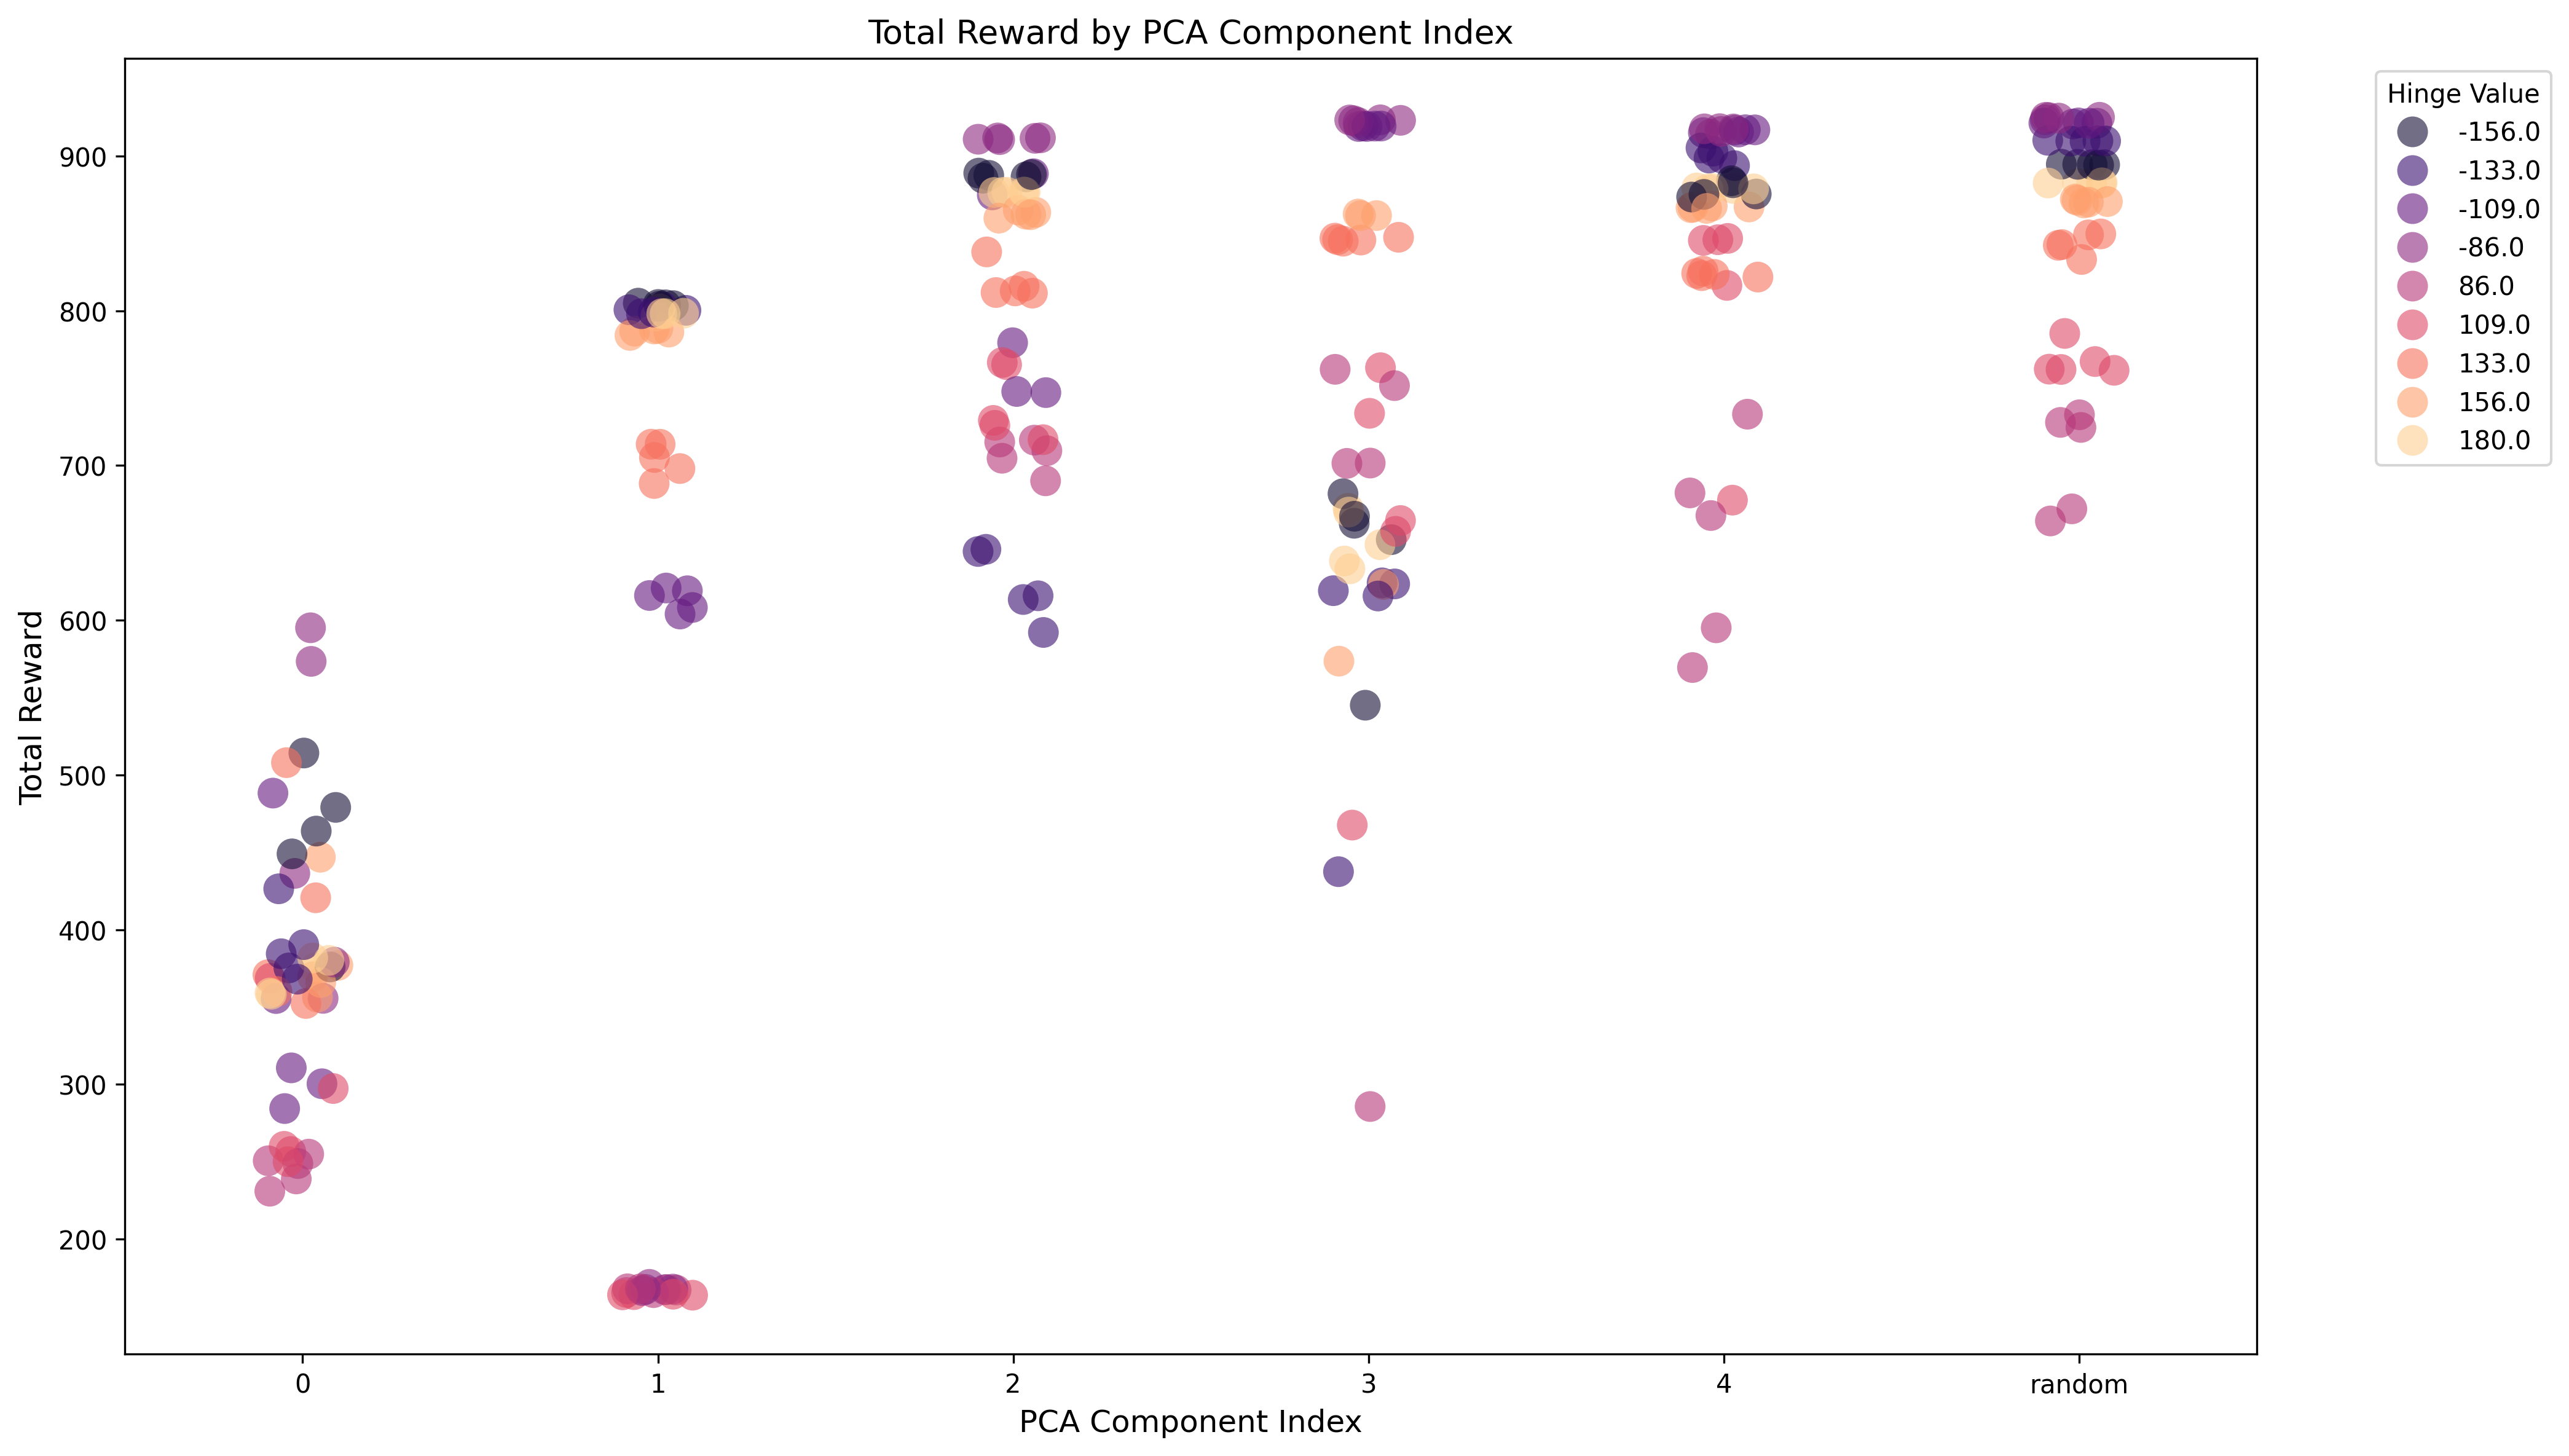

In [136]:
import seaborn as sns

# # Create a nice scatter plot with jitter, colored by config_hinge_1_value
fig, ax = plt.subplots(figsize=(14, 8), dpi=300)
sns.stripplot(data=df_direction,
              x='config_pca_component_idx',
              y='total_reward',
              hue='hinge_str',
              jitter=True,
              alpha=0.6,
              size=12,
              ax=ax,
              order=sorted(df_direction['config_pca_component_idx'].unique()),
              hue_order=sorted(df_direction['hinge_str'].unique(),
                               key=lambda x: float(x)),
              palette='magma')

# Calculate mean reward for each hinge value and PCA component
# mean_rewards = df_direction.groupby(['config_pca_component_idx', 'hinge_str'
#                                     ])['total_reward'].mean().reset_index()

# # Get the color palette used for the stripplot
# palette = sns.color_palette('viridis',
#                             n_colors=len(df_direction['hinge_str'].unique()))
# hinge_order = sorted(df_direction['hinge_str'].unique(), key=lambda x: float(x))
# color_map = {hinge: palette[i] for i, hinge in enumerate(hinge_order)}

# # Plot lines for each hinge value
# pca_components = sorted(df_direction['config_pca_component_idx'].unique())
# for hinge_val in hinge_order:
#     hinge_data = mean_rewards[mean_rewards['hinge_str'] == hinge_val]
#     # Create x positions for the line (matching the stripplot positions)
#     x_positions = [
#         pca_components.index(comp)
#         for comp in hinge_data['config_pca_component_idx']
#     ]
#     ax.plot(x_positions,
#             hinge_data['total_reward'],
#             color=color_map[hinge_val],
#             linewidth=2,
#             alpha=0.8,
#             marker='o',
#             markersize=8,
#             markeredgecolor='white',
#             markeredgewidth=1.5)

ax.set_xlabel('PCA Component Index', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('Total Reward by PCA Component Index', fontsize=13)
ax.legend(title='Hinge Value', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

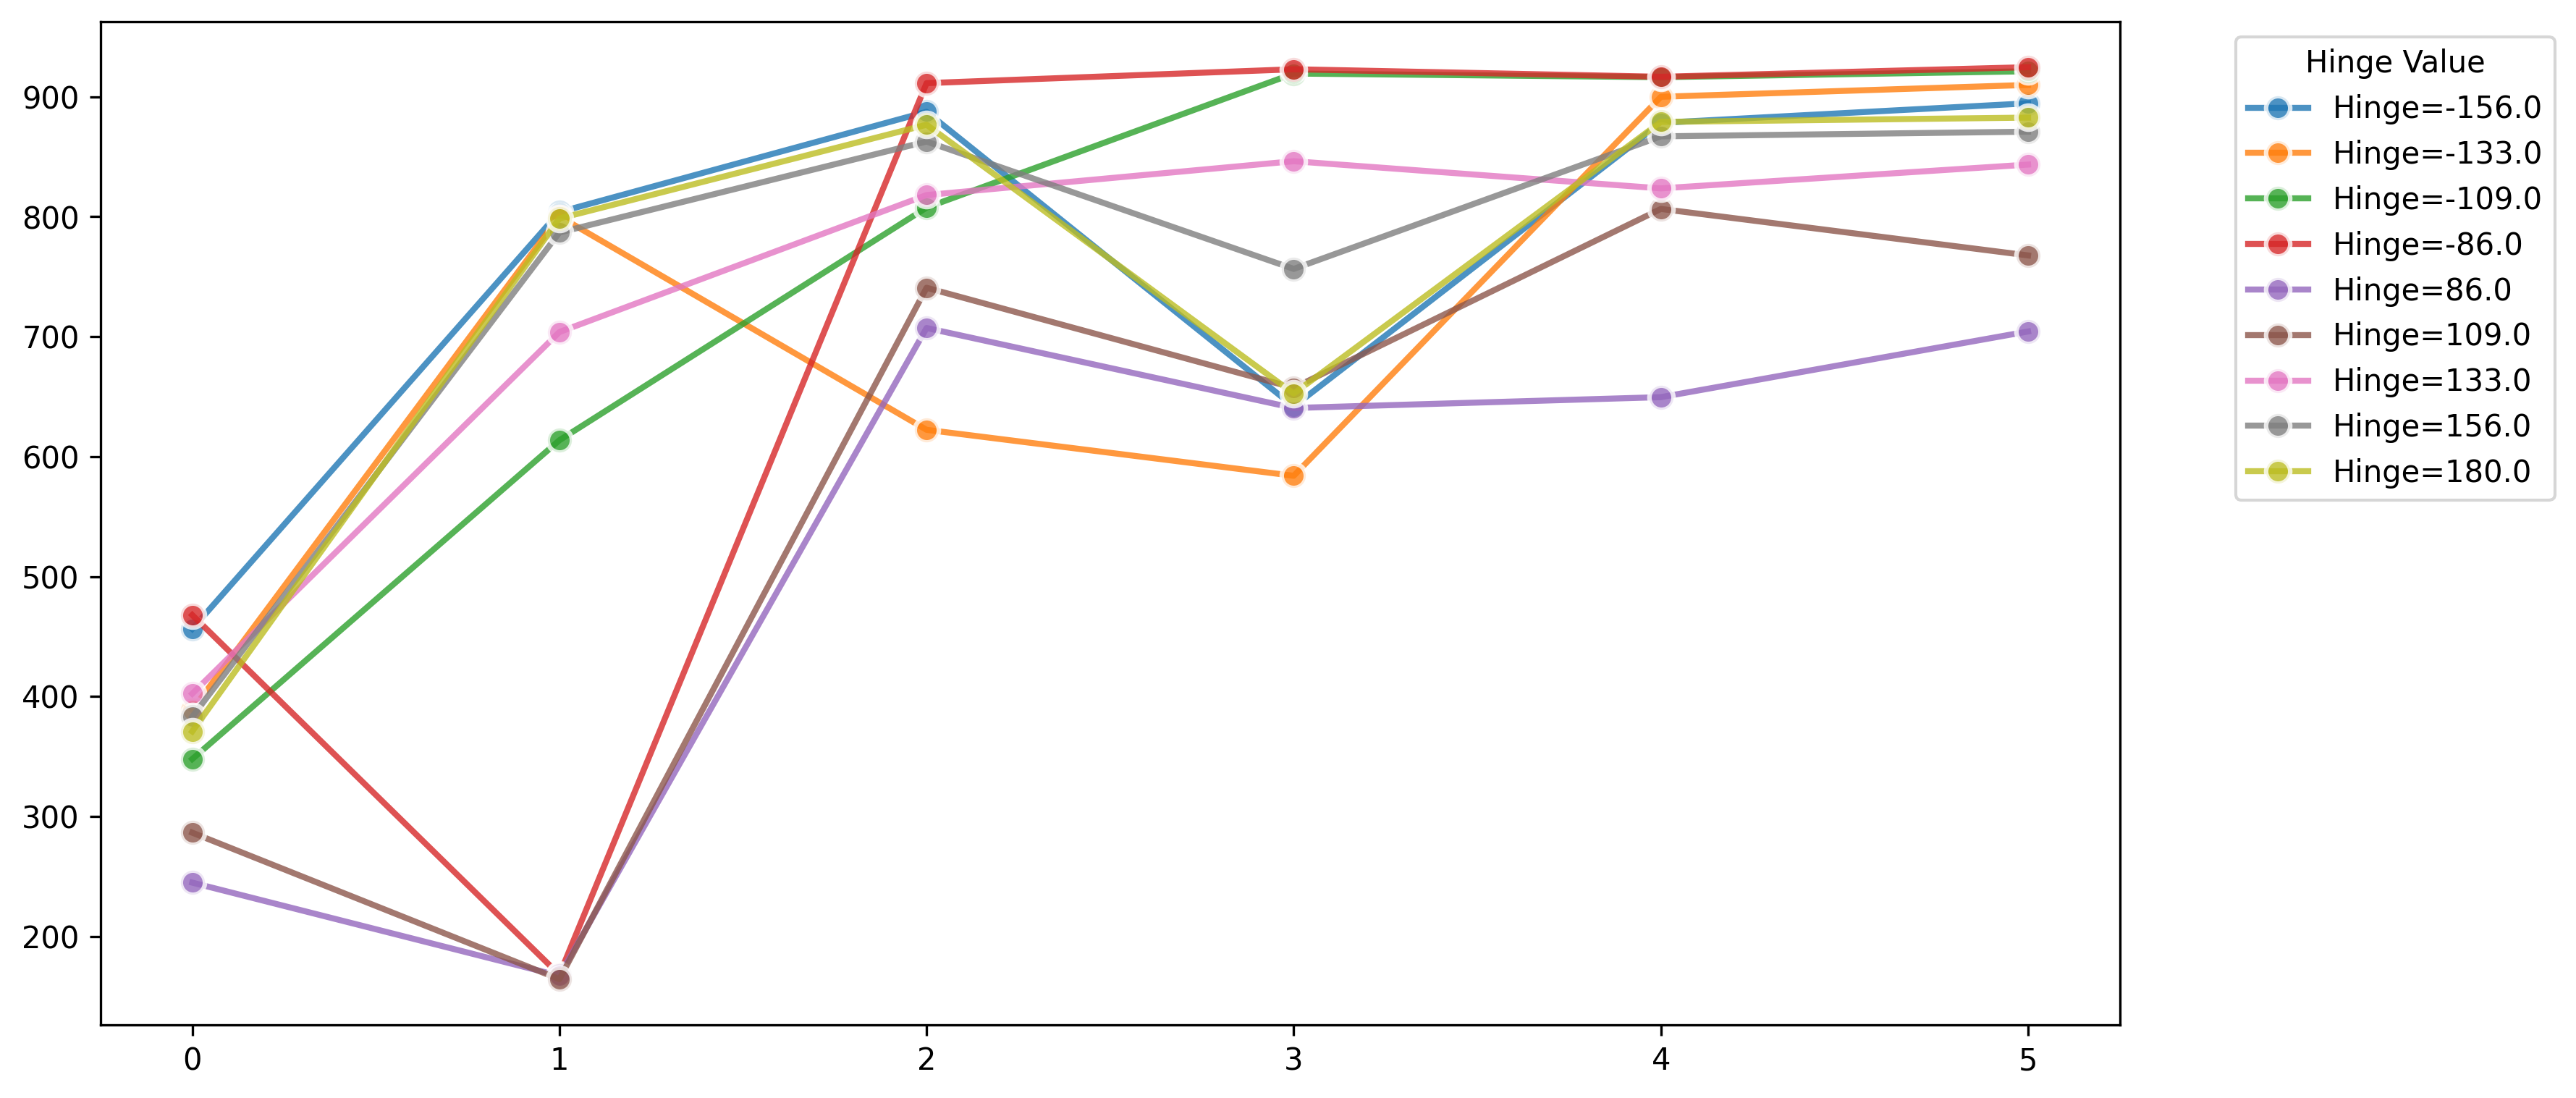

In [137]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

#Calculate mean reward for each hinge value and PCA component
mean_rewards = df_direction.groupby(['config_pca_component_idx', 'hinge_str'
                                    ])['total_reward'].mean().reset_index()

# Get the color palette used for the stripplot
palette = sns.color_palette('tab10',
                            n_colors=len(df_direction['hinge_str'].unique()))
hinge_order = sorted(df_direction['hinge_str'].unique(), key=lambda x: float(x))
color_map = {hinge: palette[i] for i, hinge in enumerate(hinge_order)}

# Plot lines for each hinge value
pca_components = sorted(df_direction['config_pca_component_idx'].unique())
for hinge_val in hinge_order:
    hinge_data = mean_rewards[mean_rewards['hinge_str'] == hinge_val]
    # Create x positions for the line (matching the stripplot positions)
    x_positions = [
        pca_components.index(comp)
        for comp in hinge_data['config_pca_component_idx']
    ]
    ax.plot(x_positions,
            hinge_data['total_reward'],
            color=color_map[hinge_val],
            linewidth=2,
            alpha=0.8,
            marker='o',
            markersize=8,
            markeredgecolor='white',
            markeredgewidth=1.5,
            label=f'Hinge={hinge_val}')

ax.legend(title='Hinge Value', bbox_to_anchor=(1.05, 1), loc='upper left')

## sensitivty of directional scaling ablation

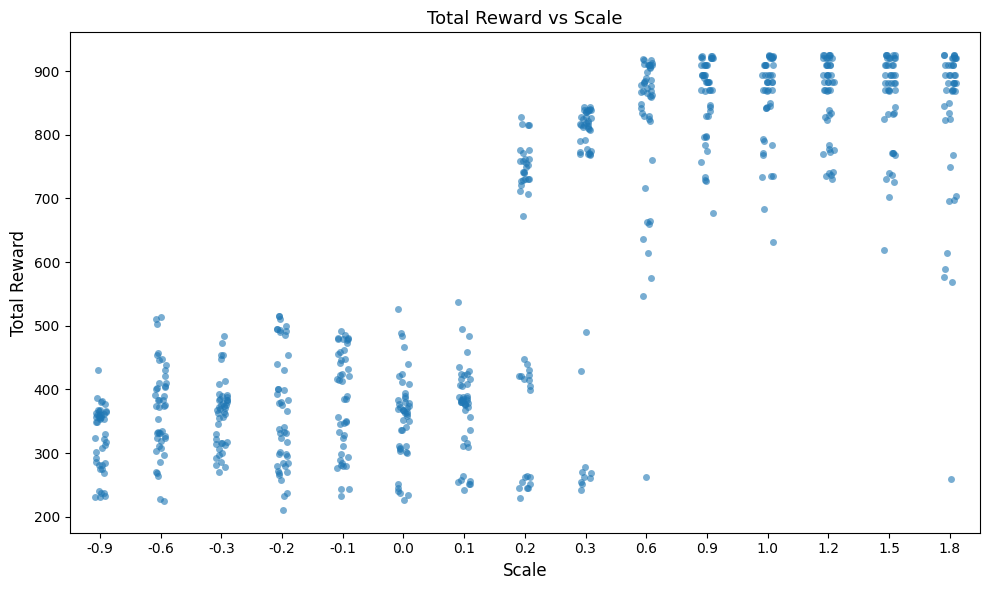

In [138]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.stripplot(data=df_pca_scale,
              x='config_scale',
              y='total_reward',
              ax=ax,
              alpha=0.6)

ax.set_xlabel('Scale', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('Total Reward vs Scale', fontsize=13)
plt.tight_layout()
plt.show()

In [140]:
df_pca_scale_data = load_intervention_data(
    df_metadata,
    intervention_type="directional_scaling_ablation",
    seed=None,
)
df_pca_scale_data = compute_success(df_pca_scale_data, consecutive_steps=100)

Found 675 configurations


100%|██████████| 675/675 [00:04<00:00, 152.42it/s]


Found 675 configurations


100%|██████████| 675/675 [00:01<00:00, 352.55it/s]


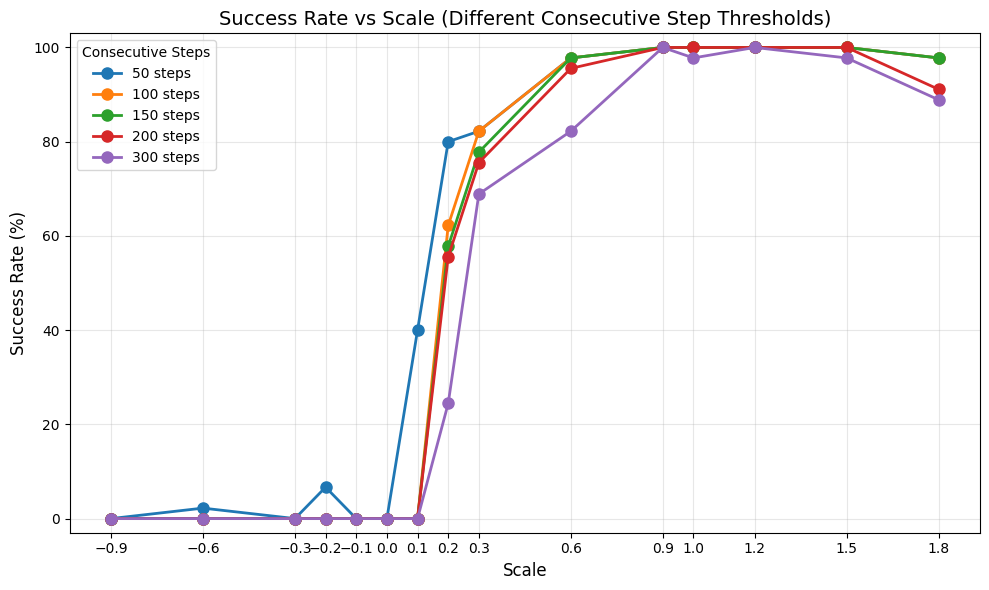

In [147]:
df_pca_scale_data = load_intervention_data(
    df_metadata,
    intervention_type="directional_scaling_ablation",
    seed=None,
)

# Define different consecutive step thresholds to test
consecutive_steps_list = [50, 100, 150, 200, 300]

# Plot
plt.figure(figsize=(10, 6))

for consecutive_steps in consecutive_steps_list:
    # Compute success for this threshold
    df_temp = compute_success(df_pca_scale_data.copy(),
                              consecutive_steps=consecutive_steps)

    # Group by scale and compute mean success rate across seeds
    success_by_scale = df_temp.groupby(
        'config_scale')['success'].mean().reset_index()
    success_by_scale.columns = ['config_scale', 'success_rate']

    # Convert success rate to percentage
    success_by_scale[
        'success_percentage'] = success_by_scale['success_rate'] * 100

    # Plot line for this threshold
    plt.plot(success_by_scale['config_scale'],
             success_by_scale['success_percentage'],
             marker='o',
             linewidth=2,
             markersize=8,
             label=f'{consecutive_steps} steps')

plt.xlabel('Scale', fontsize=12)
plt.xticks(success_by_scale['config_scale'])
plt.ylabel('Success Rate (%)', fontsize=12)
plt.title('Success Rate vs Scale (Different Consecutive Step Thresholds)',
          fontsize=14)
plt.legend(title='Consecutive Steps', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(-3, 103)
plt.show()

## lasso analysis

In [110]:
df_lasso = df_metadata[df_metadata['config_type'] == 'lasso_ablation']
variables = df_lasso['config_variable'].unique()


In [111]:
df_lasso['num_selected_dims'] = df_lasso['config_selected_dims'].apply(
    lambda x: len(x) if isinstance(x, list) else 0)

/scratch/slurm_tmpdir/job_1585100/ipykernel_1791675/3512524261.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lasso['num_selected_dims'] = df_lasso['config_selected_dims'].apply(


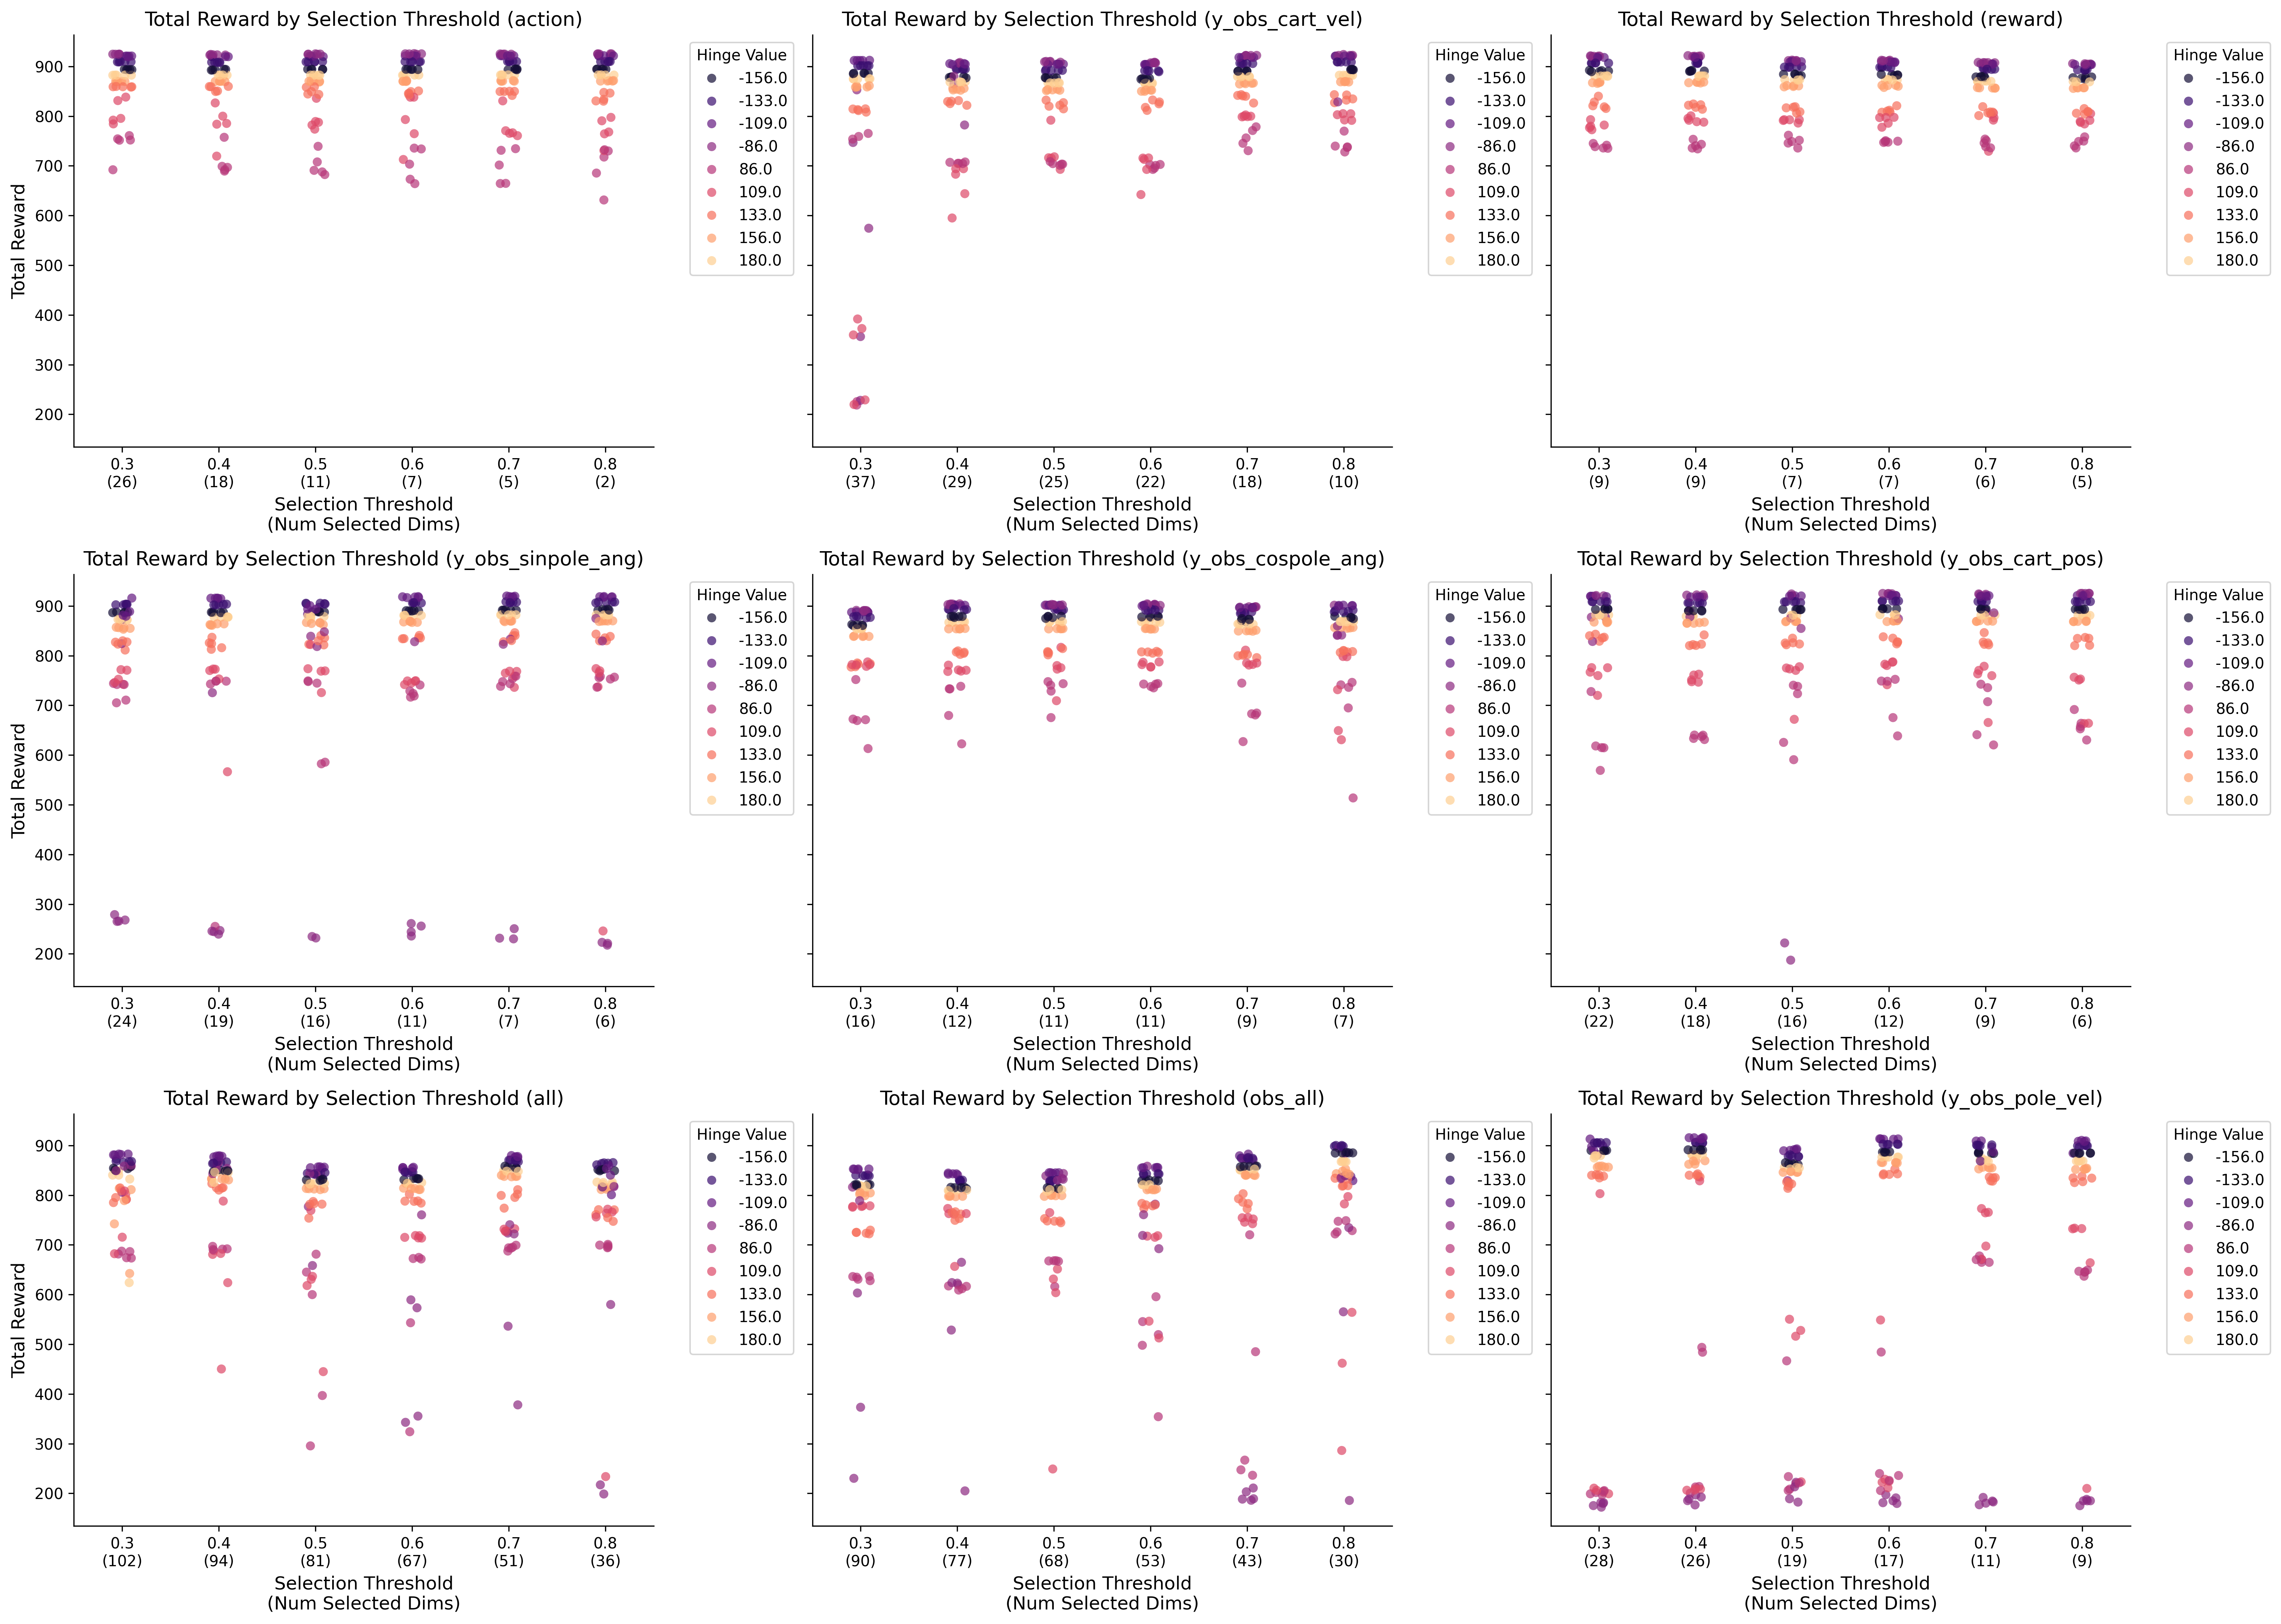

In [122]:
# Calculate number of rows needed (3 plots per row)
n_vars = len(variables)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols  # Ceiling division

# Define consistent hinge order for all plots
hinge_order = sorted(df_direction['hinge_str'].unique(), key=lambda x: float(x))

# Create figure with subplots
fig, axes = plt.subplots(n_rows,
                         n_cols,
                         figsize=(21, 5 * n_rows),
                         sharey=True,
                         dpi=300)

# Flatten axes array for easier iteration
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

# Plot for each variable
for idx, variable in enumerate(variables):
    df_var = df_lasso[df_lasso['config_variable'] == variable]
    ax = axes_flat[idx]

    # Create stripplot with ordered hue
    sns.stripplot(data=df_var,
                  x='config_selection_threshold',
                  y='total_reward',
                  hue='hinge_str',
                  hue_order=hinge_order,
                  ax=ax,
                  alpha=0.7,
                  size=6,
                  palette='magma')

    # Get unique threshold values and their corresponding num_selected_dims
    threshold_dims = df_var.groupby(
        'config_selection_threshold')['num_selected_dims'].first().sort_index()

    # Create custom tick labels
    tick_labels = [
        f"{thresh}\n({dims})" for thresh, dims in threshold_dims.items()
    ]

    # Set custom tick labels
    ax.set_xticks(range(len(threshold_dims)))
    ax.set_xticklabels(tick_labels)

    ax.set_xlabel('Selection Threshold\n(Num Selected Dims)', fontsize=12)
    ax.set_ylabel('Total Reward', fontsize=12)
    ax.set_title(f'Total Reward by Selection Threshold ({variable})',
                 fontsize=13)

    # Only show legend on first plot
    #if idx == 0:
    ax.legend(title='Hinge Value', bbox_to_anchor=(1.05, 1), loc='upper left')
    #else:
    #    ax.get_legend().remove()

# Hide any unused subplots
for idx in range(n_vars, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
sns.despine()
plt.show()

In [ ]:
df_lasso_data = load_intervention_data(
    df_metadata,
    intervention_type="lasso_ablation",
    #hinge_1_value=-1.5,
    seed=None,
    #pca_component_idx="1")
)


Found 2430 configurations


In [103]:
df_lasso_data = compute_success(df_lasso_data, consecutive_steps=100)

In [112]:
df_lasso_data['num_selected_dims'] = df_lasso_data[
    'config_selected_dims'].apply(lambda x: len(x)
                                  if isinstance(x, list) else 0)

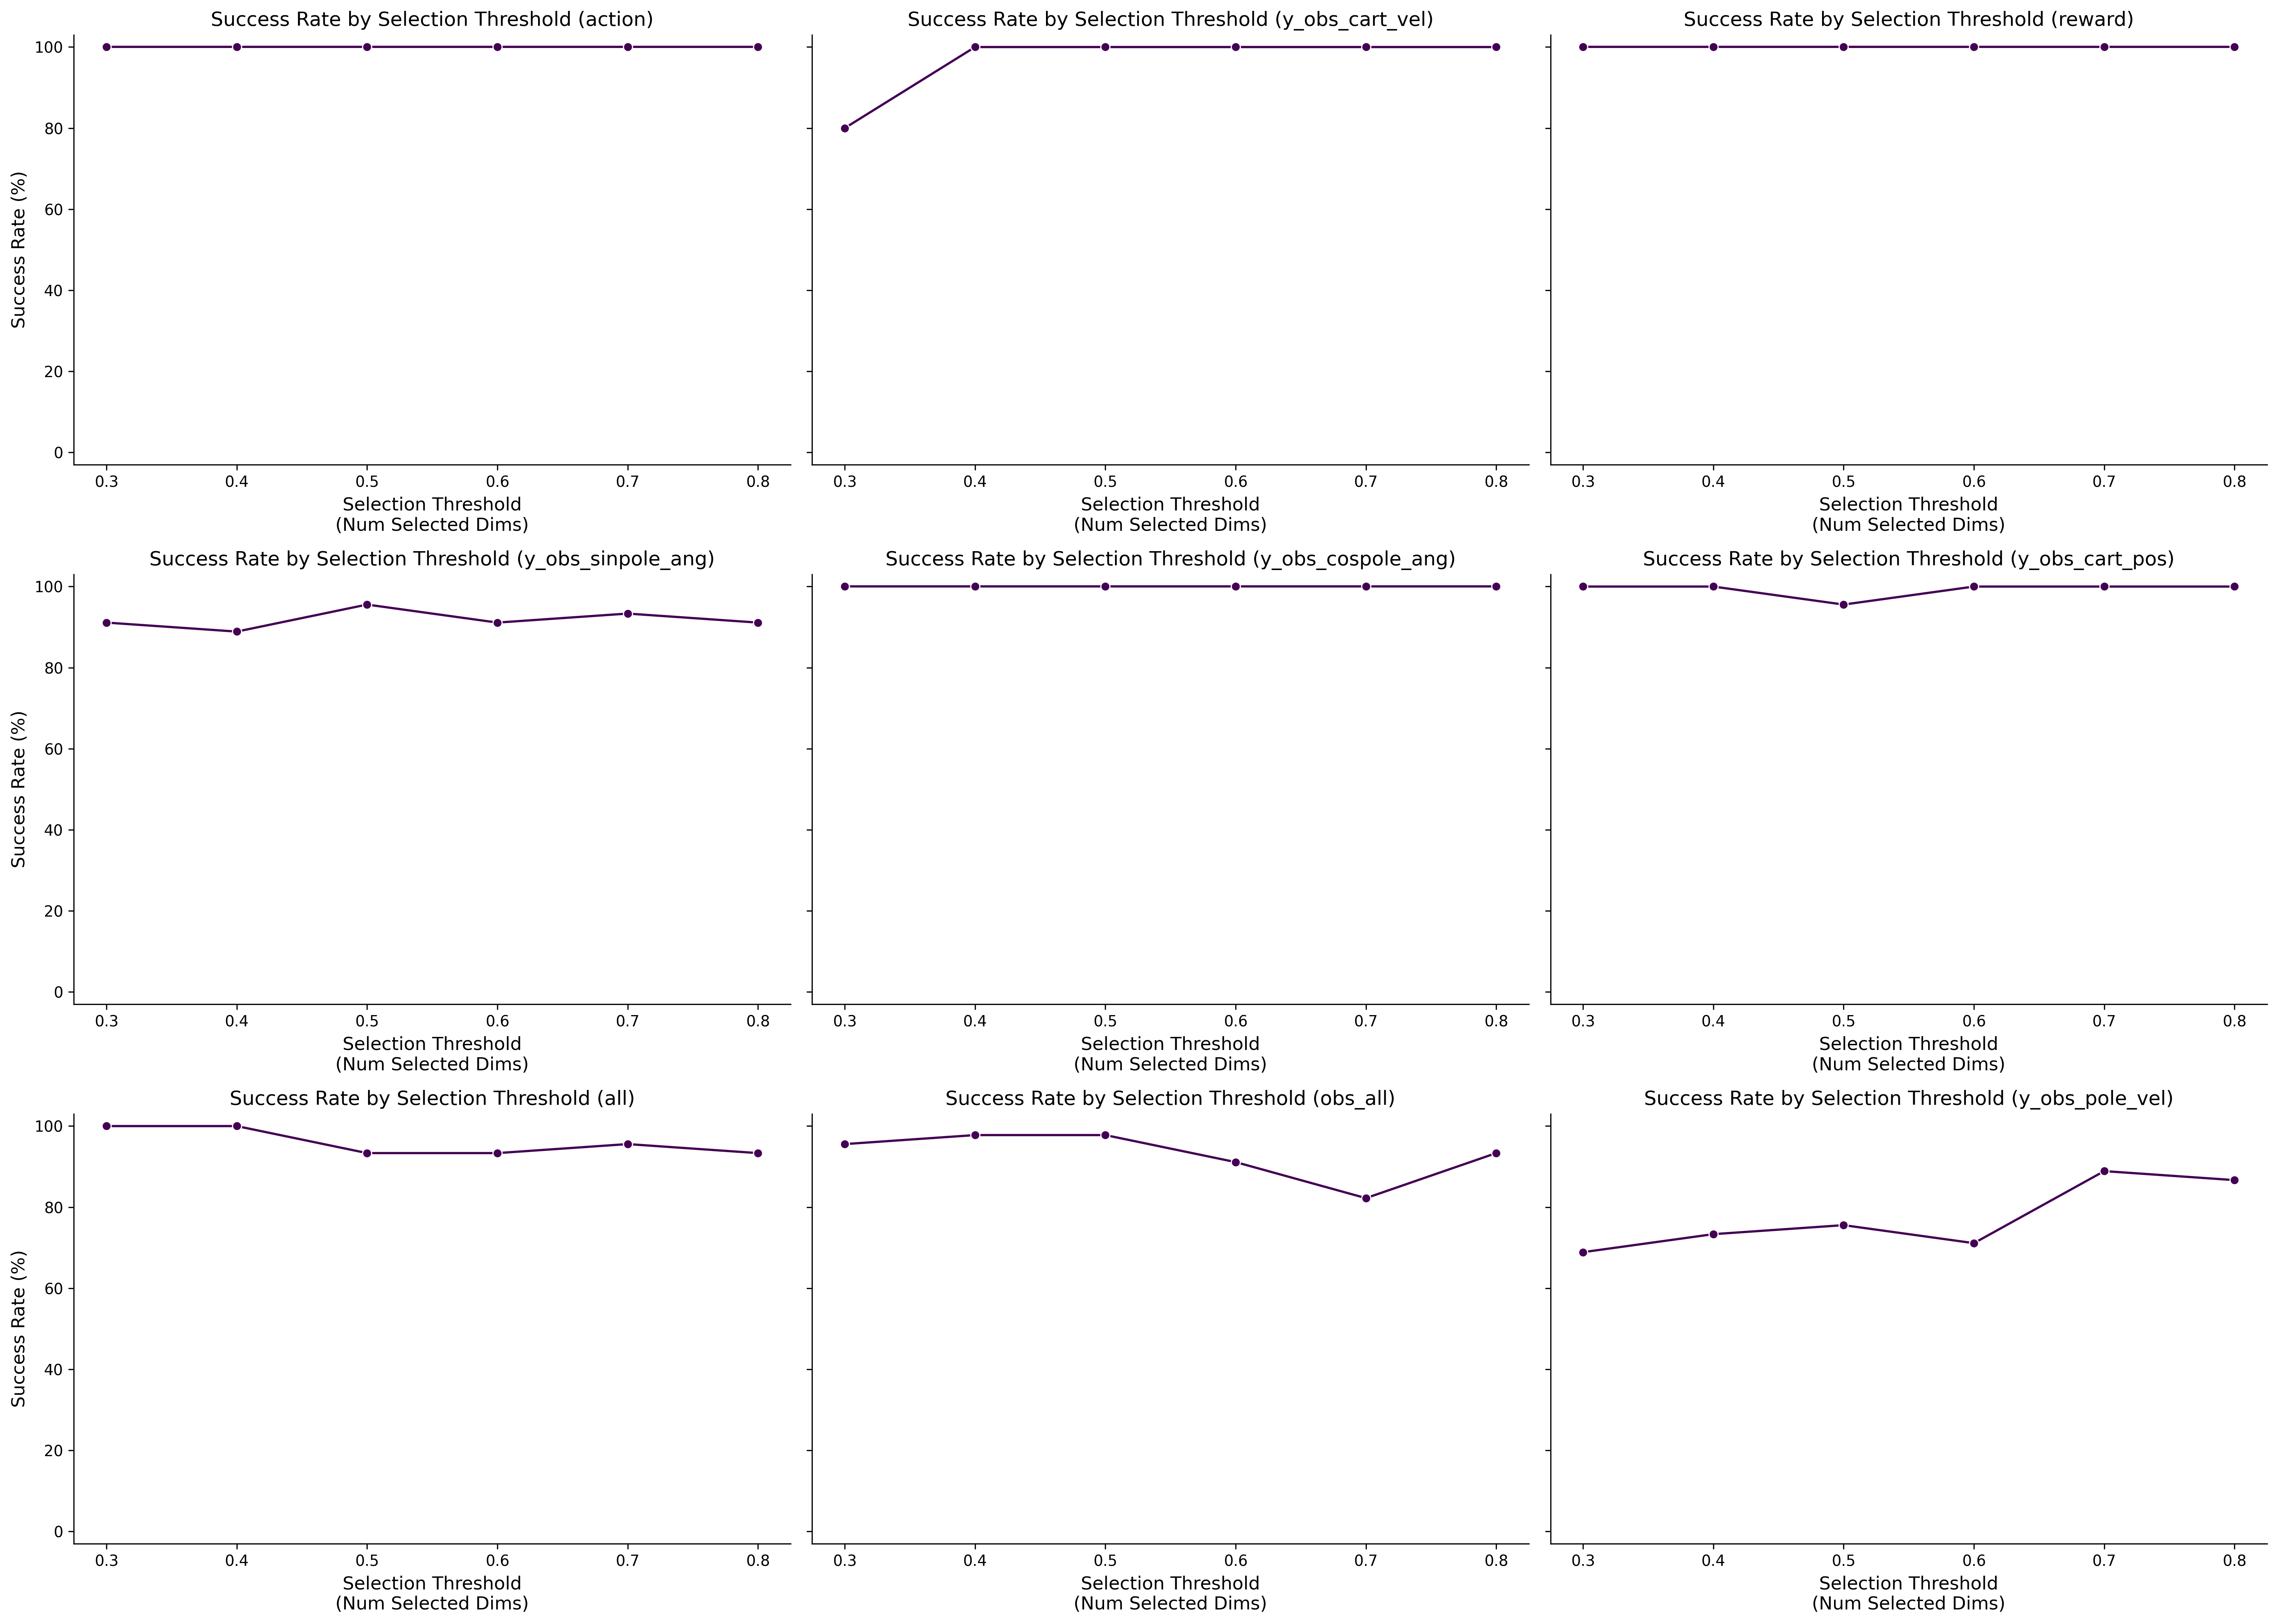

In [116]:
# Calculate number of rows needed (3 plots per row)
n_vars = len(variables)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols  # Ceiling division

# Create figure with subplots
fig, axes = plt.subplots(n_rows,
                         n_cols,
                         figsize=(21, 5 * n_rows),
                         sharey=True,
                         dpi=300)

# Flatten axes array for easier iteration
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

# Plot for each variable
for idx, variable in enumerate(variables):
    df_var = df_lasso_data[df_lasso_data['config_variable'] == variable]
    ax = axes_flat[idx]

    # Calculate mean success rate for each threshold (across all hinges)
    success_by_threshold = df_var.groupby(
        'config_selection_threshold')['success'].mean().reset_index()
    success_by_threshold[
        'success_percentage'] = success_by_threshold['success'] * 100

    # Create lineplot
    sns.lineplot(data=success_by_threshold,
                 x='config_selection_threshold',
                 y='success_percentage',
                 ax=ax,
                 marker='o',
                 markersize=6,
                 color='#440154')

    # Get unique threshold values and their corresponding num_selected_dims
    threshold_dims = df_var.groupby(
        'config_selection_threshold')['num_selected_dims'].first().sort_index()

    # # Create custom tick labels
    # tick_labels = [
    #     f"{thresh}\n({dims})" for thresh, dims in threshold_dims.items()
    # ]

    # # Set custom tick labels
    # ax.set_xticks(range(len(threshold_dims)))
    # ax.set_xticklabels(tick_labels)

    ax.set_xlabel('Selection Threshold\n(Num Selected Dims)', fontsize=12)
    ax.set_ylabel('Success Rate (%)', fontsize=12)
    ax.set_title(f'Success Rate by Selection Threshold ({variable})',
                 fontsize=13)

# Hide any unused subplots
for idx in range(n_vars, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.ylim(-3, 103)
plt.tight_layout()
sns.despine()
plt.show()

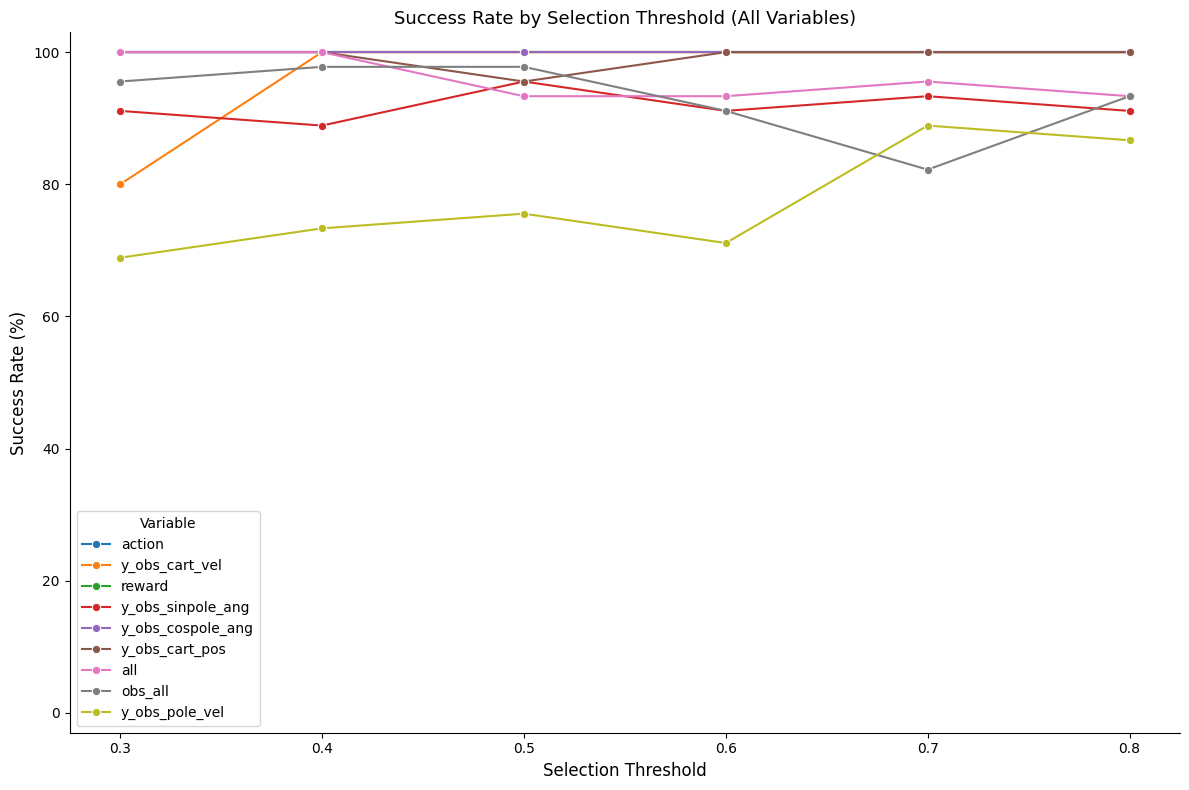

In [118]:
# Create single figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot for each variable
for idx, variable in enumerate(variables):
    df_var = df_lasso_data[df_lasso_data['config_variable'] == variable]

    # Calculate mean success rate for each threshold (across all hinges)
    success_by_threshold = df_var.groupby(
        'config_selection_threshold')['success'].mean().reset_index()
    success_by_threshold[
        'success_percentage'] = success_by_threshold['success'] * 100

    # Create lineplot
    sns.lineplot(data=success_by_threshold,
                 x='config_selection_threshold',
                 y='success_percentage',
                 ax=ax,
                 marker='o',
                 markersize=6,
                 label=variable)

ax.set_xlabel('Selection Threshold', fontsize=12)
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_title('Success Rate by Selection Threshold (All Variables)', fontsize=13)
ax.legend(title='Variable', fontsize=10)

plt.ylim(-3, 103)
plt.tight_layout()
sns.despine()
plt.show()

In [76]:
df_directional_ablation_data = load_intervention_data(
    df_metadata,
    intervention_type="directional_ablation",
    #hinge_1_value=-1.5,
    seed=None,
    #pca_component_idx="1")
)

Found 225 configurations


In [100]:
df_directional_ablation_data = compute_success(df_directional_ablation_data,
                                               consecutive_steps=100)

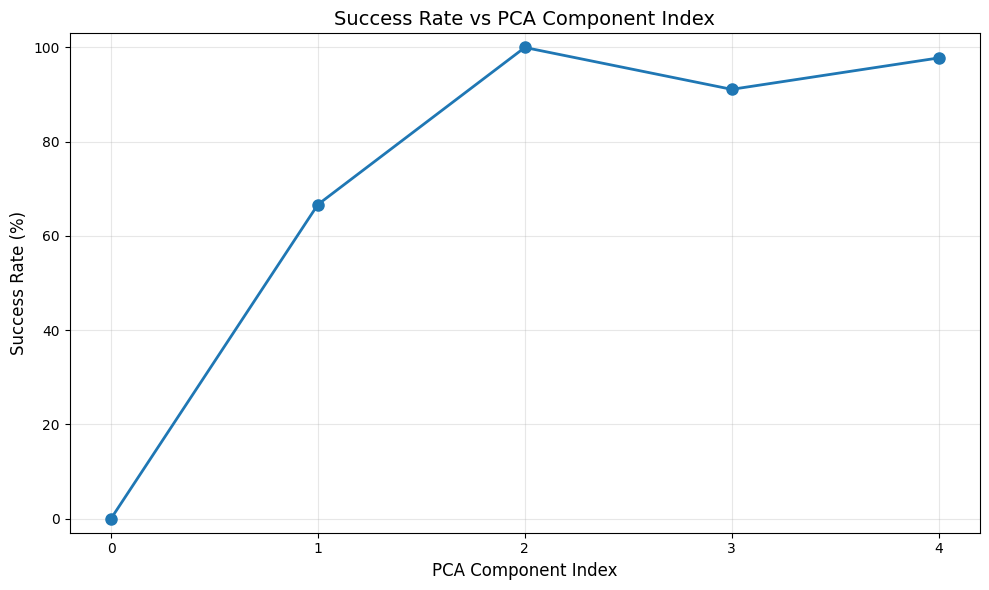

  pca_component_idx  success_rate  success_percentage
0                 0      0.000000            0.000000
1                 1      0.666667           66.666667
2                 2      1.000000          100.000000
3                 3      0.911111           91.111111
4                 4      0.977778           97.777778


In [ ]:
# Group by PCA component index and compute mean success rate across seeds
success_by_pca = df_directional_ablation_data.groupby(
    'config_pca_component_idx')['success'].mean().reset_index()
success_by_pca.columns = ['pca_component_idx', 'success_rate']

# Convert success rate to percentage
success_by_pca['success_percentage'] = success_by_pca['success_rate'] * 100

# Plot
plt.figure(figsize=(10, 6))
plt.plot(success_by_pca['pca_component_idx'],
         success_by_pca['success_percentage'],
         marker='o',
         linewidth=2,
         markersize=8)
plt.xlabel('PCA Component Index', fontsize=12)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.title('Success Rate vs PCA Component Index', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(-3, 103)
plt.show()


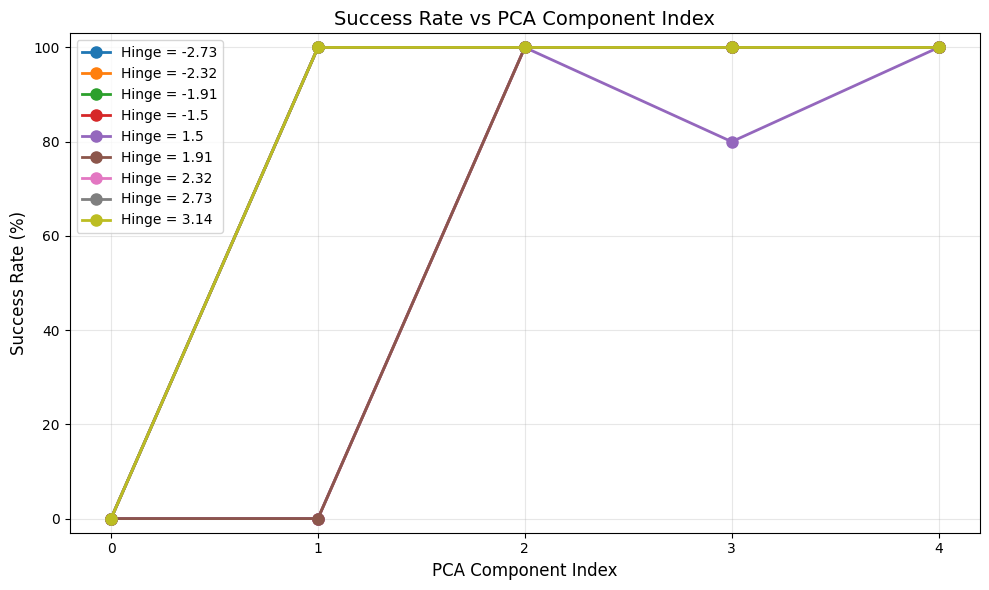

In [101]:
# Group by PCA component index and hinge value, compute mean success rate across seeds
success_by_pca_hinge = df_directional_ablation_data.groupby(
    ['config_pca_component_idx',
     'config_hinge_1_value'])['success'].mean().reset_index()
success_by_pca_hinge.columns = [
    'pca_component_idx', 'hinge_value', 'success_rate'
]

# Convert success rate to percentage
success_by_pca_hinge[
    'success_percentage'] = success_by_pca_hinge['success_rate'] * 100

# Plot
plt.figure(figsize=(10, 6))
for hinge_value in success_by_pca_hinge['hinge_value'].unique():
    data = success_by_pca_hinge[success_by_pca_hinge['hinge_value'] ==
                                hinge_value]
    plt.plot(data['pca_component_idx'],
             data['success_percentage'],
             marker='o',
             linewidth=2,
             markersize=8,
             label=f'Hinge = {hinge_value}')
plt.xlabel('PCA Component Index', fontsize=12)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.title('Success Rate vs PCA Component Index', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(-3, 103)
plt.show()

## plotting latents

In [158]:
idx = 4
latents = df_directional_ablation_data['latent_states'].iloc[idx].T
rewards = df_directional_ablation_data['rewards'].iloc[idx]
actions = df_directional_ablation_data['actions'].iloc[idx]

print(np.sum(rewards))
#print(np.sum(actions))


167.43169116709032


In [160]:
model, y, isort, X_embedding = fit_rastermap(latents,
                                             n_PCs=200,
                                             n_clusters=100,
                                             locality=0.75,
                                             time_lag_window=10)

2025-11-17 14:17:57,485 [INFO] normalizing data across axis=1
2025-11-17 14:17:57,488 [INFO] projecting out mean along axis=0
2025-11-17 14:17:57,490 [INFO] data normalized, 0.00sec
2025-11-17 14:17:57,491 [INFO] sorting activity: 512 valid samples by 500 timepoints
2025-11-17 14:17:57,531 [INFO] n_PCs = 200 computed, 0.05sec
2025-11-17 14:17:57,618 [INFO] 100 clusters computed, time 0.13sec
2025-11-17 14:18:53,879 [INFO] clusters sorted, time 56.39sec
2025-11-17 14:18:53,925 [INFO] clusters upsampled, time 56.44sec
2025-11-17 14:18:53,928 [INFO] rastermap complete, time 56.44sec


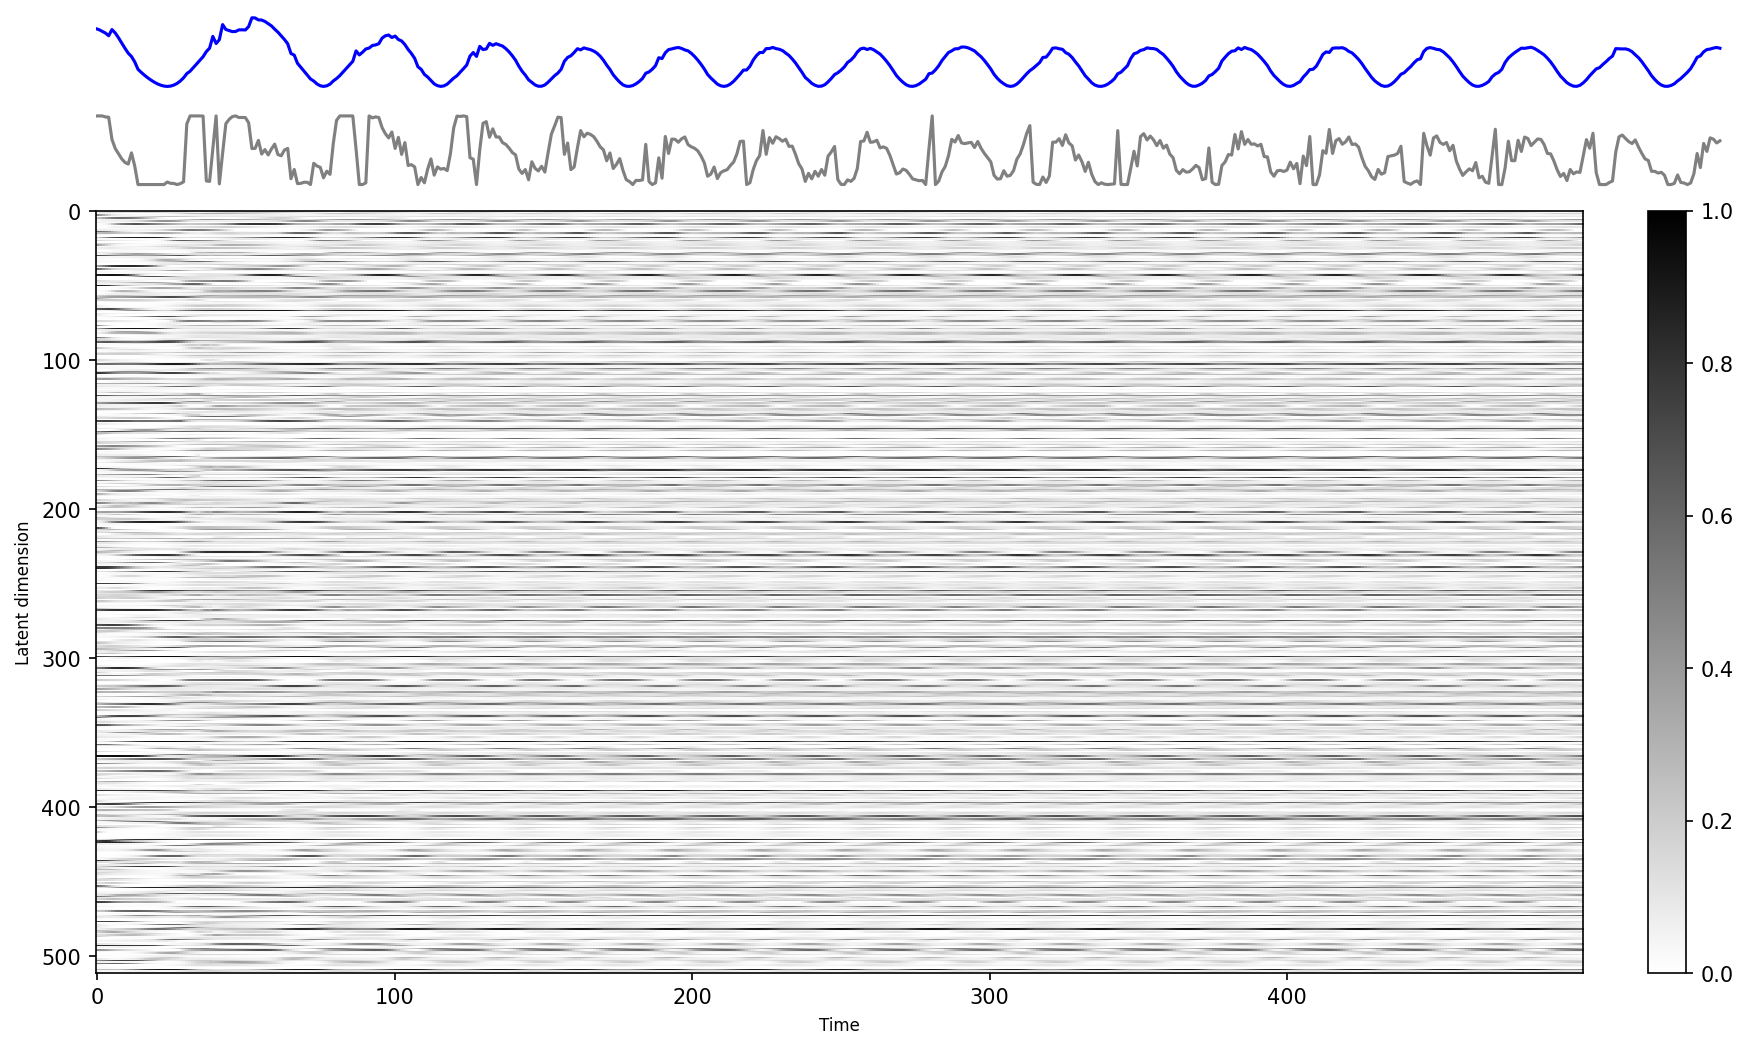

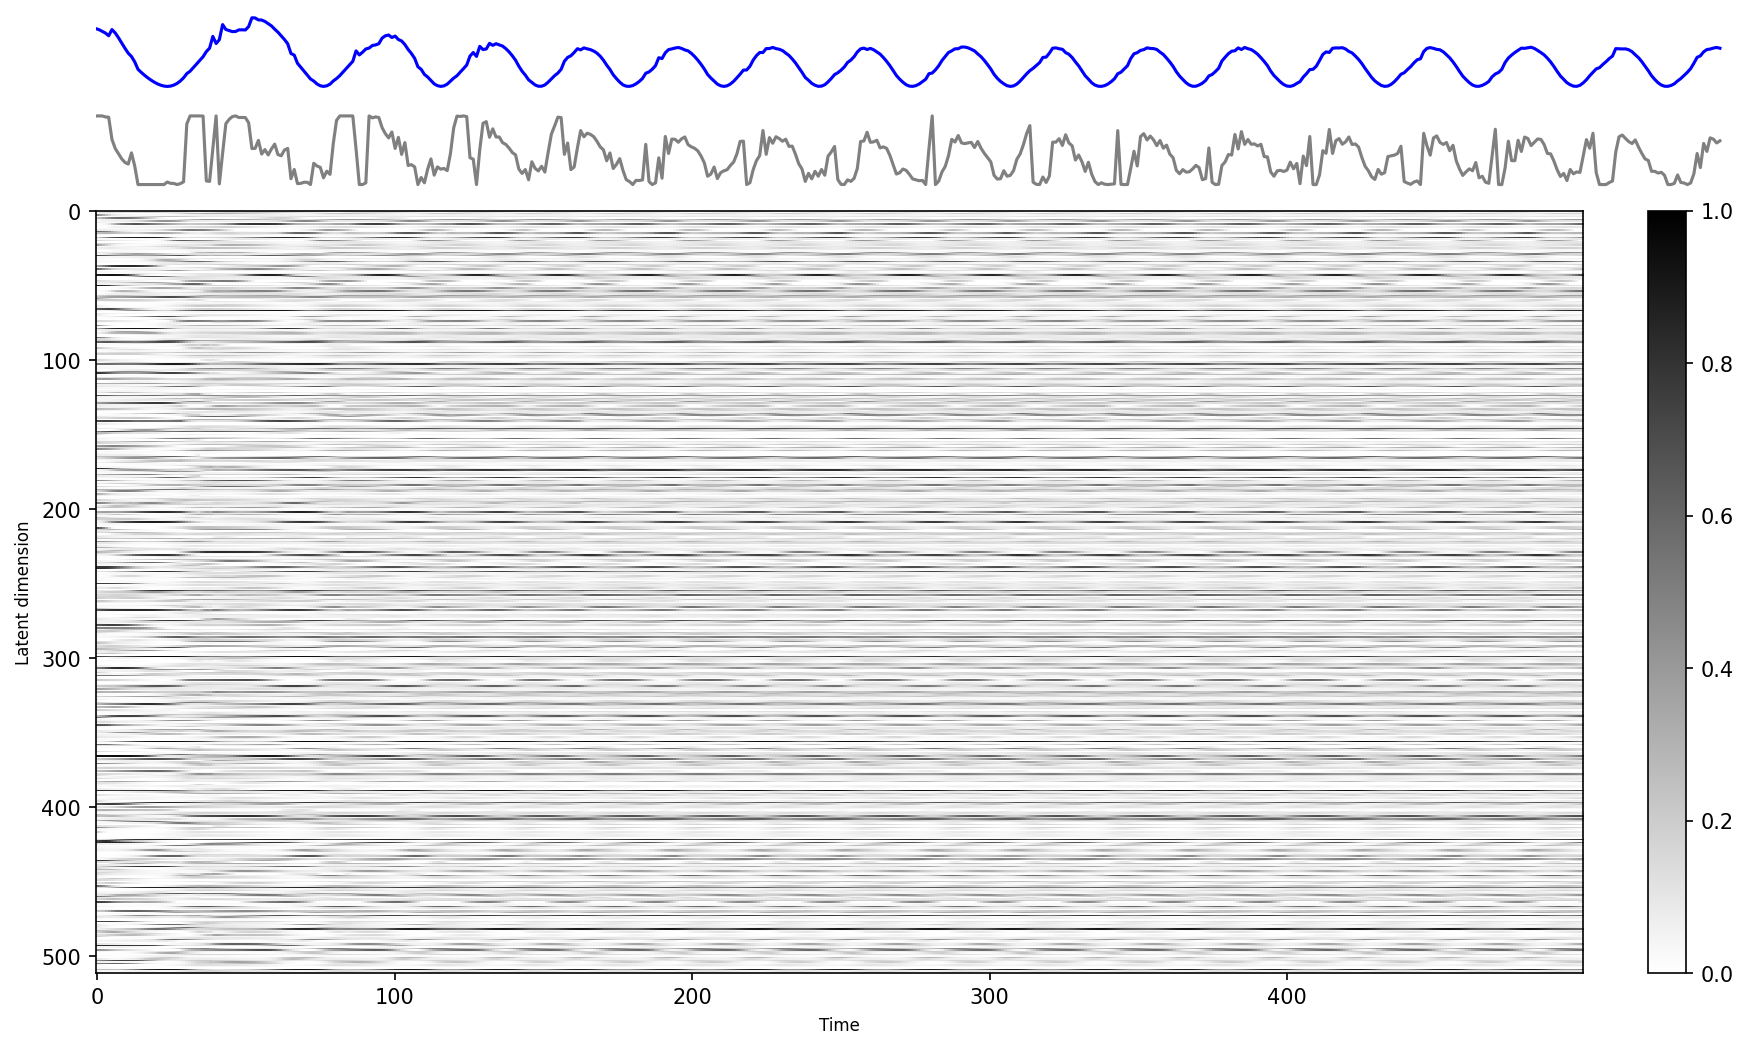

In [161]:
plot_rastermap_with_rewards_actions(rewards=rewards,
                                    actions=actions,
                                    latents=latents,
                                    plot_type='latents',
                                    sort_latents=False)


In [8]:
states = np.array(df_directional_ablation_data['observations'].iloc[0])

In [18]:
df_directional_ablation_data.keys()

Index(['config_type', 'config_location', 'config_selected_dims',
       'config_selection_type', 'config_selection_threshold',
       'config_variable', 'config_hinge_1_value', 'config_seed', 'checkpoint',
       'task', 'latent_dim', 'episode_idx', 'episode_length', 'total_reward',
       'timestamp', 'obs_type', 'directory', 'config_direction',
       'config_pca_component_idx', 'config_hinge_1_value_degrees', 'hinge_str',
       'observations', 'actions', 'rewards', 'dones', 'latent_states',
       'timesteps'],
      dtype='object')

In [25]:
states_radians = np.arctan2(states[:, 2], states[:, 1])

In [17]:
states.shape

(500, 5)

In [22]:
states[0, :2]

array([0.01624345, 0.0707372 ], dtype=float32)

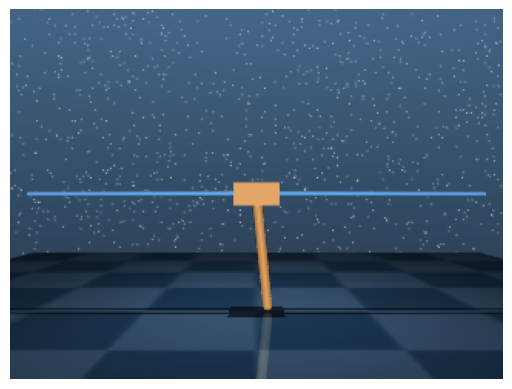

In [ ]:
#os.environ["PYOPENGL_PLATFORM"] = "egl"

from dm_control import suite
import matplotlib.pyplot as plt
import numpy as np

# Dummy state example
# states = np.load("states.npy")

env = suite.load("cartpole", "swingup")
env.reset()

env.physics.data.qpos[:] = np.array([0, states_radians[200]])
env.physics.data.qvel[:] = states[0, 2:4]
env.physics.forward()

frame = env.physics.render(height=240, width=320, camera_id=0)

plt.imshow(frame)
plt.axis("off")
plt.show()


In [61]:
def reconstruct_frame(states, env, height=240, width=320, camera_id=0):
    env.physics.data.qpos[0] = states[0]
    env.physics.data.qpos[1] = states[1]
    env.physics.data.qvel[0] = states[2]
    env.physics.data.qvel[1] = states[3]
    env.physics.forward()
    frame = env.physics.render(height=height, width=width, camera_id=camera_id)
    return frame


def reconstruct_cartpole_dmcontrol(states, height=240, width=320, camera_id=0):
    import os
    os.environ["MUJOCO_GL"] = "egl"  # critical for Jupyter
    env = suite.load("cartpole", "swingup")
    pole_angle_radians = np.arctan2(states[:, 2], states[:, 1]).reshape(-1, 1)
    states_radians = np.concatenate([
        states[:, 0].reshape(-1, 1),
        pole_angle_radians.reshape(-1, 1), states[:, 2:4]
    ],
                                    axis=1)
    assert states_radians.shape[1] == 4

    frames = []
    for state in tqdm(states_radians):
        frame = reconstruct_frame(state, env, height, width, camera_id)
        frames.append(frame)
    return frames

In [62]:
video_frames = reconstruct_cartpole_dmcontrol(states)

 12%|█▏        | 62/500 [00:01<00:11, 39.26it/s]


KeyboardInterrupt: 

In [58]:
# write video
import imageio

out_path = "cartpole_reconstruction.mp4"
imageio.mimwrite(out_path, video_frames, fps=30, macro_block_size=None)
print(f"Wrote {len(video_frames)} frames to {os.path.abspath(out_path)}")


/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/imageio_ffmpeg/_utils.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Wrote 500 frames to /hkfs/home/haicore/hgf_hmgu/hgf_gib4562/tdmpc2/cartpole_reconstruction.mp4


In [63]:
import pickle

pkl_path = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/171125-latent_interventions_guided_sweep/20251116_203816/activations/episode_0000.pkl"
with open(pkl_path, 'rb') as f:
    episode_data = pickle.load(f)

print(f"Loaded episode data from {pkl_path}")
print(f"Keys: {episode_data.keys()}")


Loaded episode data from /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/171125-latent_interventions_guided_sweep/20251116_203816/activations/episode_0000.pkl
Keys: dict_keys(['metadata', 'data'])


In [65]:
episode_data['metadata'].keys()

dict_keys(['config', 'checkpoint', 'task', 'latent_dim', 'episode_idx', 'episode_length', 'total_reward', 'timestamp', 'obs_type'])